# Global Housing Market Analysis (2015-2024)
# MATH 014 - Introduction to Data Science Final Project
## Shreeya Gautam 

In [59]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import seaborn as sns
sns.set(style='whitegrid')

In [5]:
# Load the dataset
df = pd.read_csv('global_housing_market_extended.csv')

# 1. DATA UNDERSTANDING AND CLEANING

In [7]:
# View first few rows
df.head()

,Country,Year,House Price Index,Rent Index,Affordability Ratio,Mortgage Rate (%),Inflation Rate (%),GDP Growth (%),Population Growth (%),Urbanization Rate (%),Construction Index
0,USA,2015,117.454012,116.550001,9.587945,4.493292,1.514121,-0.752044,-0.796707,85.985284,118.089201
1,USA,2016,150.807258,51.440915,11.729189,5.662213,1.880204,-0.545400,-0.358084,69.127267,111.980515
2,USA,2017,123.194502,70.386040,8.506676,2.197469,2.398940,0.930895,0.596245,83.555279,85.973903
3,USA,2018,131.423444,91.469020,3.418054,4.537724,1.608407,-1.479587,2.321099,88.968961,134.671788
4,USA,2019,110.461377,56.837048,9.158097,3.700762,1.293249,1.961415,-0.879640,87.279612,90.702399


In [9]:
# Check datatypes and structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                200 non-null    object 
 1   Year                   200 non-null    int64  
 2   House Price Index      200 non-null    float64
 3   Rent Index             200 non-null    float64
 4   Affordability Ratio    200 non-null    float64
 5   Mortgage Rate (%)      200 non-null    float64
 6   Inflation Rate (%)     200 non-null    float64
 7   GDP Growth (%)         200 non-null    float64
 8   Population Growth (%)  200 non-null    float64
 9   Urbanization Rate (%)  200 non-null    float64
 10  Construction Index     200 non-null    float64
dtypes: float64(9), int64(1), object(1)
memory usage: 17.3+ KB


In [11]:
# Check column names and missing values
print(df.columns)
print(df.isnull().sum())

Index(['Country', 'Year', 'House Price Index', 'Rent Index',
       'Affordability Ratio', 'Mortgage Rate (%)', 'Inflation Rate (%)',
       'GDP Growth (%)', 'Population Growth (%)', 'Urbanization Rate (%)',
       'Construction Index'],
      dtype='object')
Country                  0
Year                     0
House Price Index        0
Rent Index               0
Affordability Ratio      0
Mortgage Rate (%)        0
Inflation Rate (%)       0
GDP Growth (%)           0
Population Growth (%)    0
Urbanization Rate (%)    0
Construction Index       0
dtype: int64


In [13]:
# Standardize column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [15]:
# Handle missing values (example: fill numeric with median, drop rows otherwise)
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df = df.dropna()

In [17]:
# Remove duplicates
df = df.drop_duplicates()

In [19]:
# Convert 'year' to categorical if present
if 'year' in df.columns:
    df['year'] = df['year'].astype('category')

In [21]:
df.columns = df.columns.str.strip()

In [23]:
# Rename columns for easier access
df.rename(columns={
    'country': 'Country',
    'year': 'Year',
    'house_price_index': 'House Price Index',
    'rent_index': 'Rent Index',
    'affordability_ratio': 'Affordability Ratio',
    'mortgage_rate_(%)': 'Mortgage Rate (%)',
    'inflation_rate_(%)': 'Inflation Rate (%)',
    'gdp_growth_(%)': 'GDP Growth (%)',
    'population_growth_(%)': 'Population Growth (%)',
    'urbanization_rate_(%)': 'Urbanization Rate (%)',
    'construction_index': 'Construction Index'
}, inplace=True)

In [25]:
# Basic overview
print(df.head())
print(df.info())

  Country  Year  House Price Index  Rent Index  Affordability Ratio  \
0     USA  2015         117.454012  116.550001             9.587945   
1     USA  2016         150.807258   51.440915            11.729189   
2     USA  2017         123.194502   70.386040             8.506676   
3     USA  2018         131.423444   91.469020             3.418054   
4     USA  2019         110.461377   56.837048             9.158097   

   Mortgage Rate (%)  Inflation Rate (%)  GDP Growth (%)  \
0           4.493292            1.514121       -0.752044   
1           5.662213            1.880204       -0.545400   
2           2.197469            2.398940        0.930895   
3           4.537724            1.608407       -1.479587   
4           3.700762            1.293249        1.961415   

   Population Growth (%)  Urbanization Rate (%)  Construction Index  
0              -0.796707              85.985284          118.089201  
1              -0.358084              69.127267          111.980515  
2 

In [27]:
print(df.columns.tolist())
# Check for negative values in 'Mortgage Rate(%) '
print("Negative Mortgage Rates:", (df['Mortgage Rate (%)'] < 0).sum())
print("Negative Inflation Rates:", (df['Inflation Rate (%)'] < 0).sum())
print("Negative House Price Index:", (df['House Price Index'] < 0).sum())

['Country', 'Year', 'House Price Index', 'Rent Index', 'Affordability Ratio', 'Mortgage Rate (%)', 'Inflation Rate (%)', 'GDP Growth (%)', 'Population Growth (%)', 'Urbanization Rate (%)', 'Construction Index']
Negative Mortgage Rates: 0
Negative Inflation Rates: 0
Negative House Price Index: 0


In [29]:
# Describe dataset
print("\nDescriptive Statistics:\n", df.describe())


Descriptive Statistics:
        House Price Index  Rent Index  Affordability Ratio  Mortgage Rate (%)  \
count         200.000000  200.000000           200.000000         200.000000   
mean          130.381022   83.048370             7.237768           4.150621   
std            28.752229   21.439858             2.576085           1.380222   
min            80.552212   50.354311             3.041688           1.537814   
25%           104.142562   60.466671             5.034207           3.045278   
50%           129.193653   83.721711             7.375697           4.329643   
75%           157.127098  100.604665             9.276196           5.217706   
max           179.971767  119.855388            11.879671           6.485623   

       Inflation Rate (%)  GDP Growth (%)  Population Growth (%)  \
count          200.000000      200.000000             200.000000   
mean             3.649756        2.133722               0.722806   
std              1.881938        2.413270        

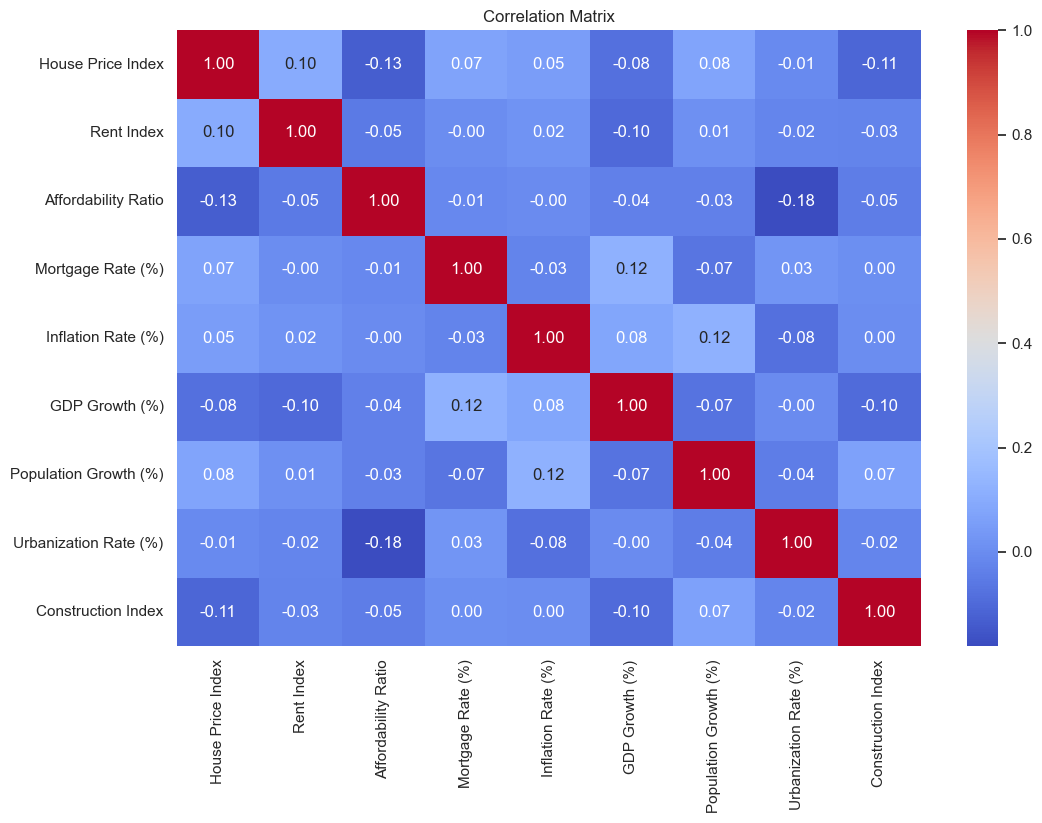

In [31]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

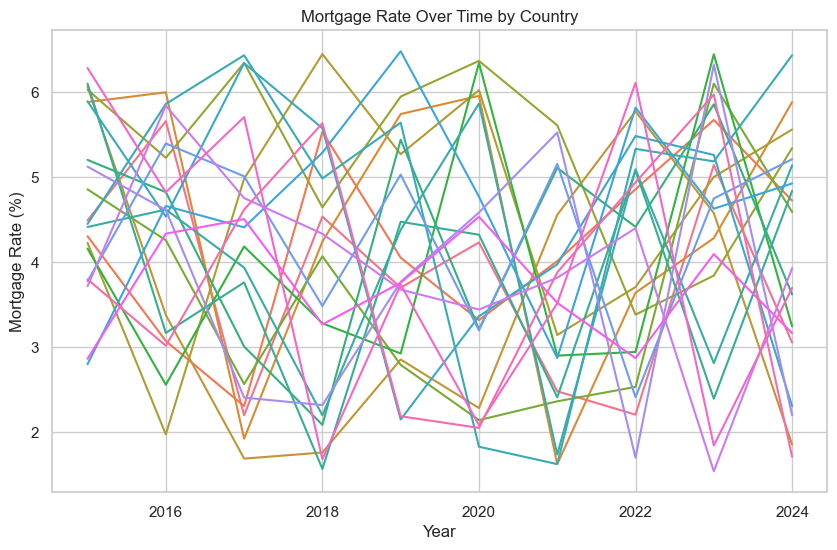

In [33]:
# Visualization: Mortgage Rate Over Time
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Year', y='Mortgage Rate (%)', hue='Country', legend=False)
plt.title("Mortgage Rate Over Time by Country")
plt.xlabel("Year")
plt.ylabel("Mortgage Rate (%)")
plt.show()

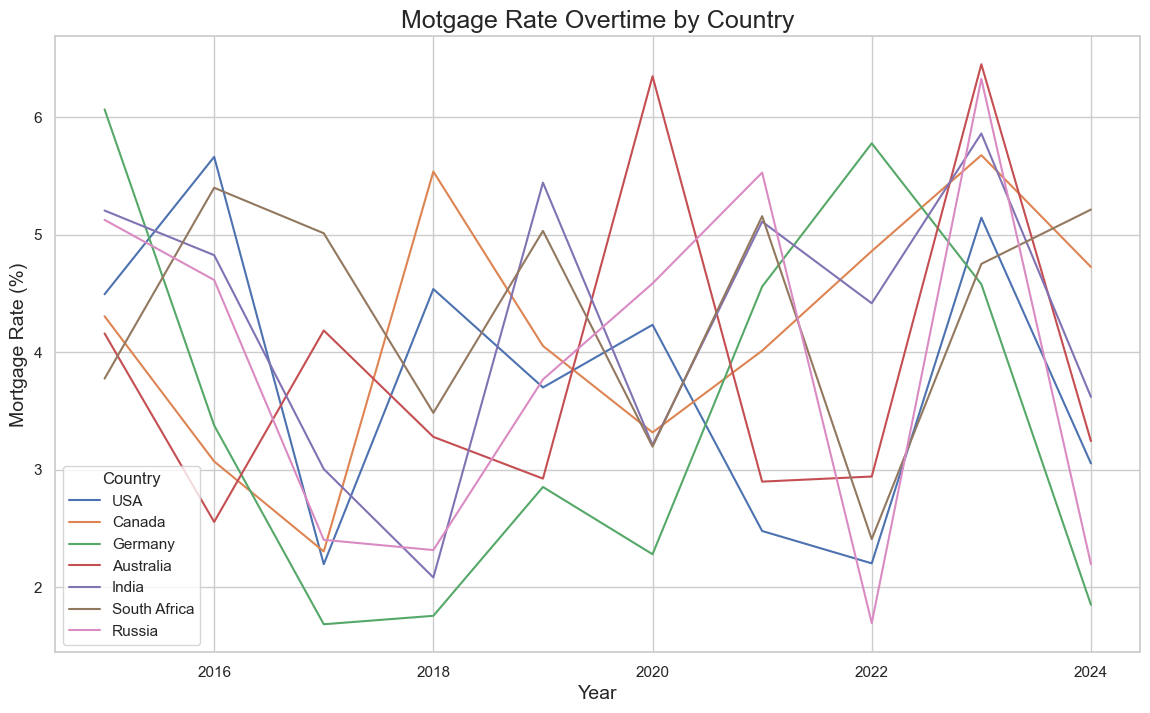

In [35]:
# narrowing down the countries for clear visualization

plt.figure(figsize=(14,8))
countries_to_plot = ['USA', 'Canada', 'Germany', 'Australia', 'India', 'South Africa', 'Russia']


for country in countries_to_plot:
    plt.plot(
        df[df['Country'] == country]['Year'],
        df[df['Country'] == country]['Mortgage Rate (%)'],
        label=country
    )

plt.title('Motgage Rate Overtime by Country', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Mortgage Rate (%)', fontsize=14)
plt.legend(title="Country")
plt.grid(True)
plt.show()

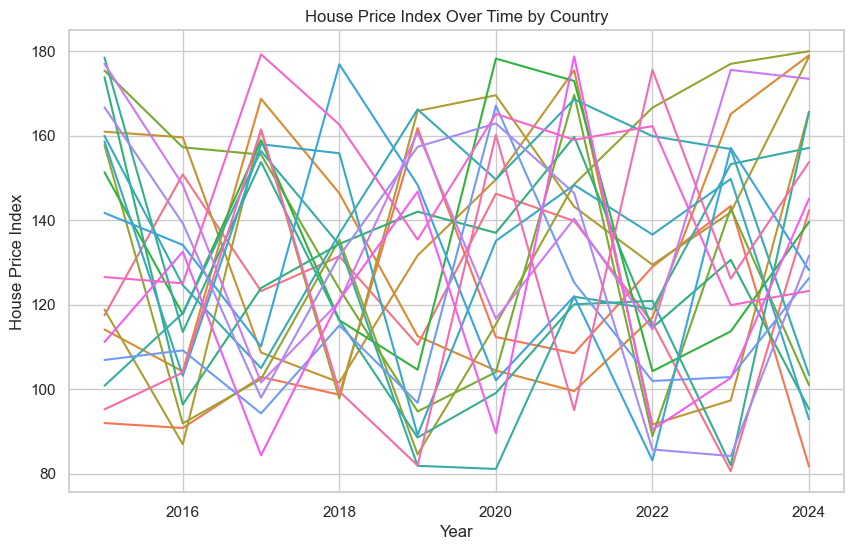

In [72]:
#  Visualization: House Price Index Trend

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Year', y='House Price Index', hue='Country', legend=False)
plt.title("House Price Index Over Time by Country")
plt.xlabel("Year")
plt.ylabel("House Price Index")
plt.show()

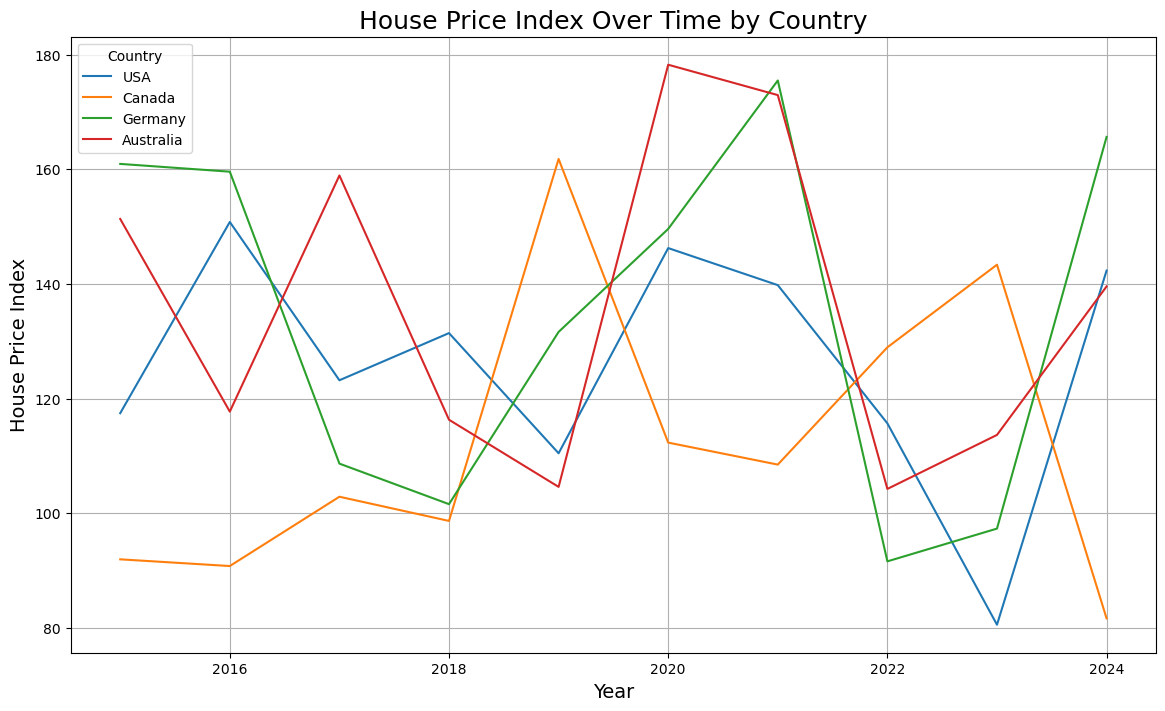

In [145]:

# narrowing down the countries for clear visualization

plt.figure(figsize=(14,8))

for country in countries_to_plot:
    plt.plot(
        df[df['Country'] == country]['Year'],
        df[df['Country'] == country]['House Price Index'],
        label=country
    )

plt.title('House Price Index Over Time by Country', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('House Price Index', fontsize=14)
plt.legend(title="Country")
plt.grid(True)
plt.show()


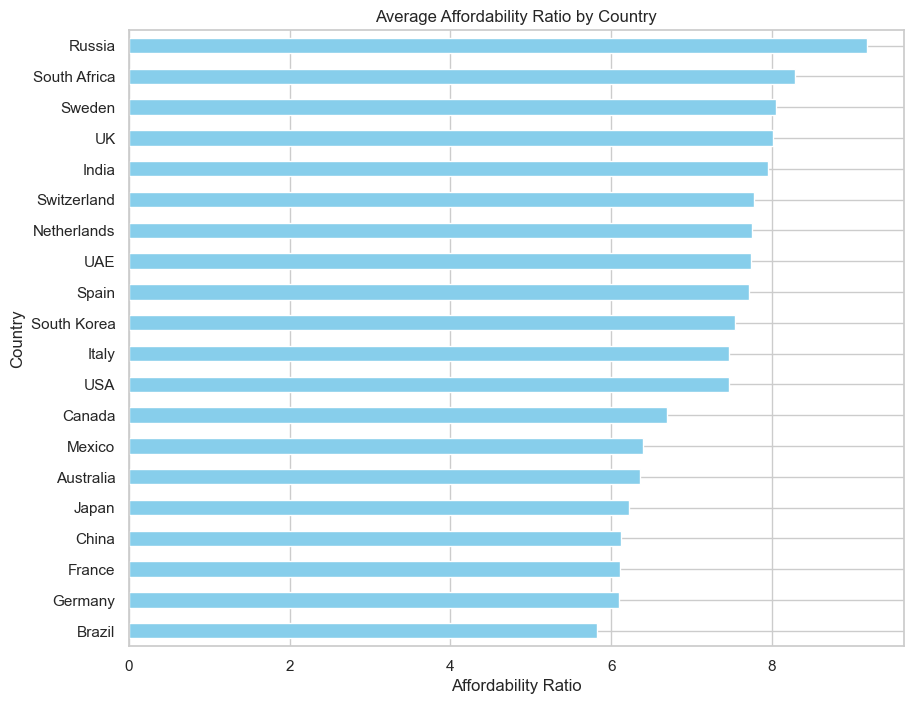

In [37]:
# Average affordability ratio per country
affordability_by_country = df.groupby('Country')['Affordability Ratio'].mean().sort_values()

plt.figure(figsize=(10, 8))
affordability_by_country.plot(kind='barh', color='skyblue')
plt.title("Average Affordability Ratio by Country")
plt.xlabel("Affordability Ratio")
plt.show()

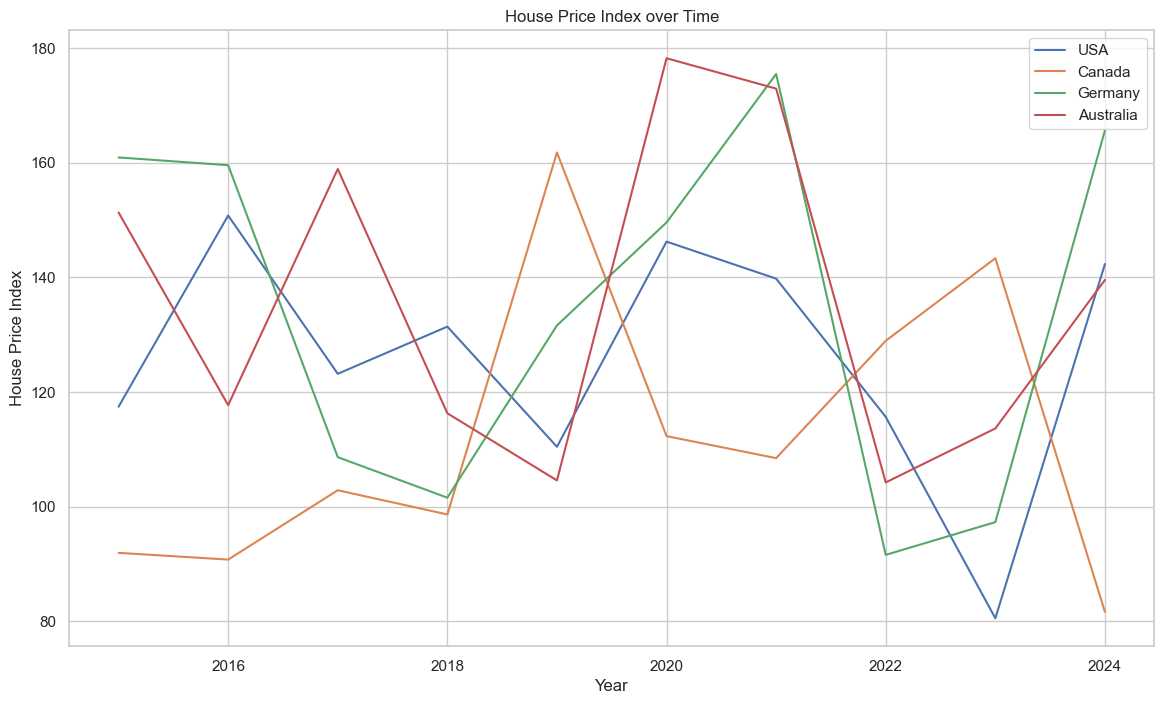

In [39]:
# Select a few countries to plot
countries_to_plot = ['USA', 'Canada', 'Germany', 'Australia']

# 6.1 House Price Index over Time
plt.figure(figsize=(14,8))
for country in countries_to_plot:
    subset = df[df['Country'] == country]  # 'Country' is correct here
    plt.plot(subset['Year'], subset['House Price Index'], label=country)  # Updated column name
plt.legend()
plt.xlabel('Year')
plt.ylabel('House Price Index')
plt.title('House Price Index over Time')
plt.show()

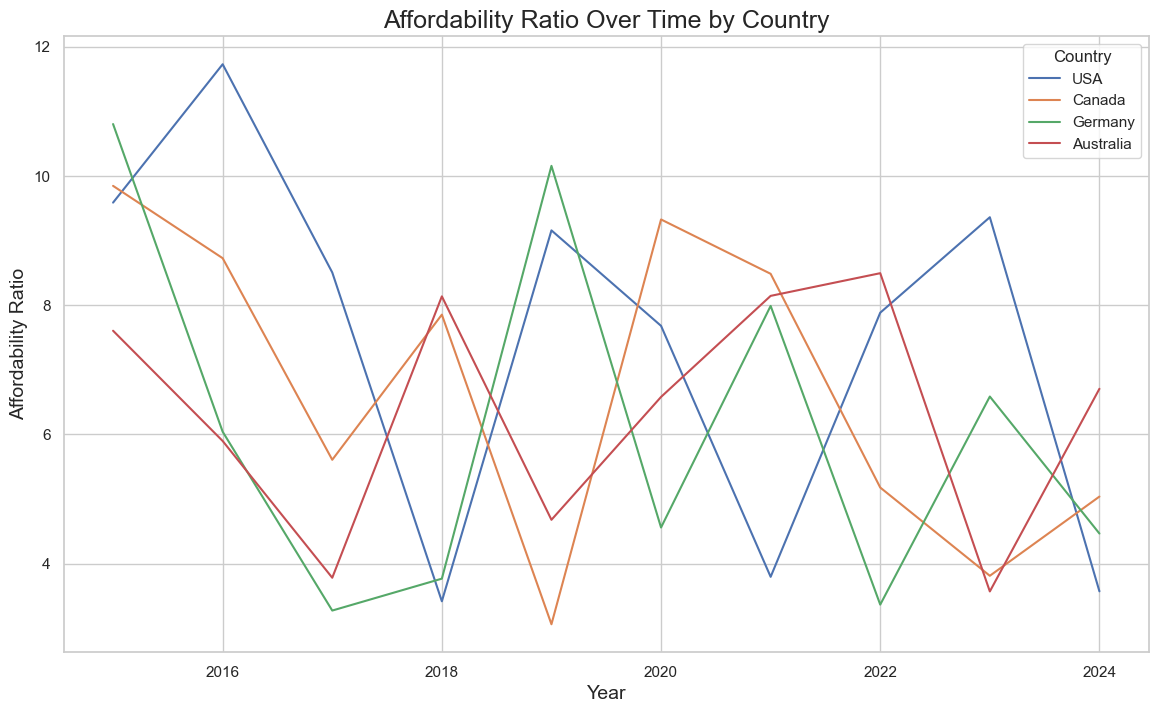

In [41]:
# 6.2 Affordability Ratio over Time
plt.figure(figsize=(14,8))
for country in countries_to_plot:
    subset = df[df['Country'] == country]
    plt.plot(subset['Year'], subset['Affordability Ratio'], label=country)  # Updated column name

plt.title('Affordability Ratio Over Time by Country', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Affordability Ratio', fontsize=14)
plt.legend(title="Country")
plt.grid(True)
plt.show()

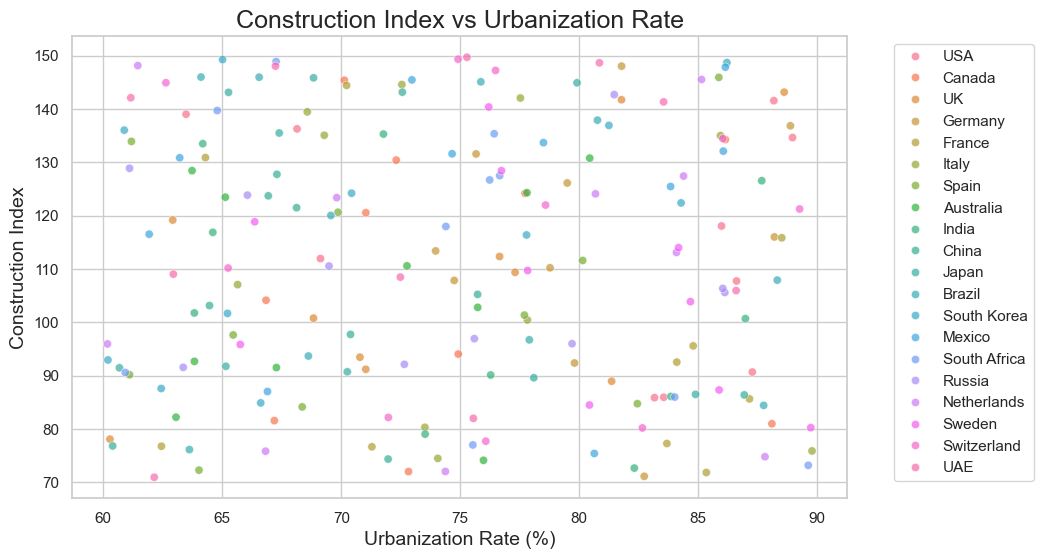

In [43]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Urbanization Rate (%)', y='Construction Index', hue='Country', alpha=0.7)  # Corrected column names
plt.title('Construction Index vs Urbanization Rate', fontsize=18)
plt.xlabel('Urbanization Rate (%)', fontsize=14)
plt.ylabel('Construction Index', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

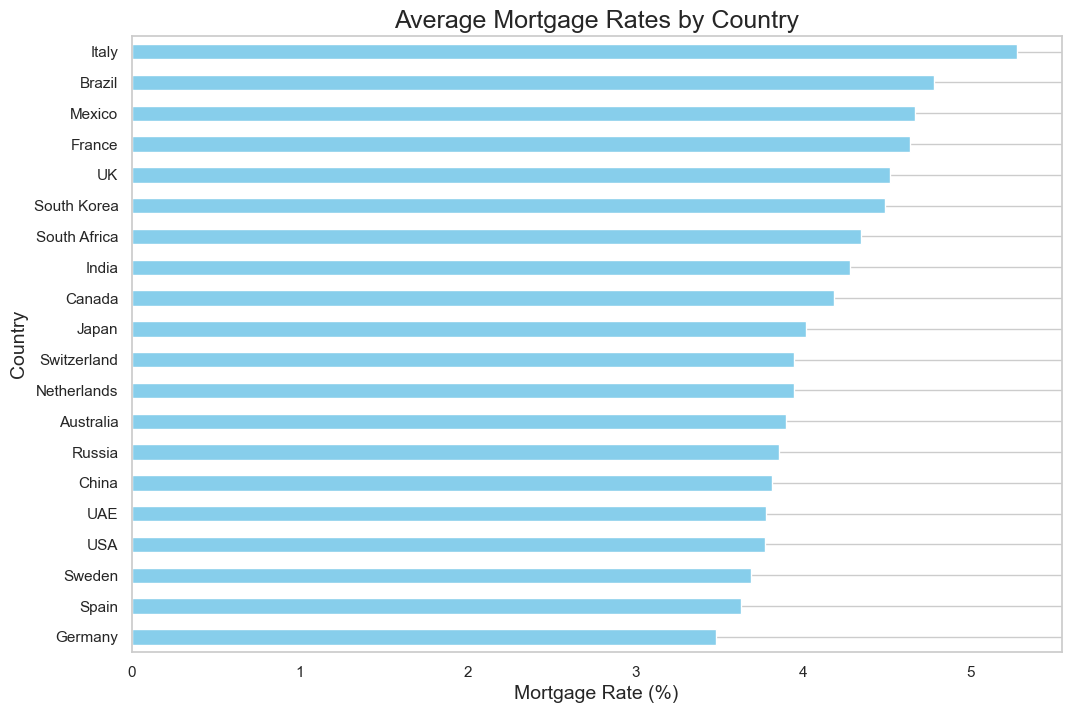

In [45]:
avg_mortgage_rates = df.groupby('Country')['Mortgage Rate (%)'].mean().sort_values()  # Corrected column names

plt.figure(figsize=(12,8))
avg_mortgage_rates.plot(kind='barh', color='skyblue')
plt.title('Average Mortgage Rates by Country', fontsize=18)
plt.xlabel('Mortgage Rate (%)', fontsize=14)
plt.ylabel('Country', fontsize=14)
plt.grid(axis='x')
plt.show()

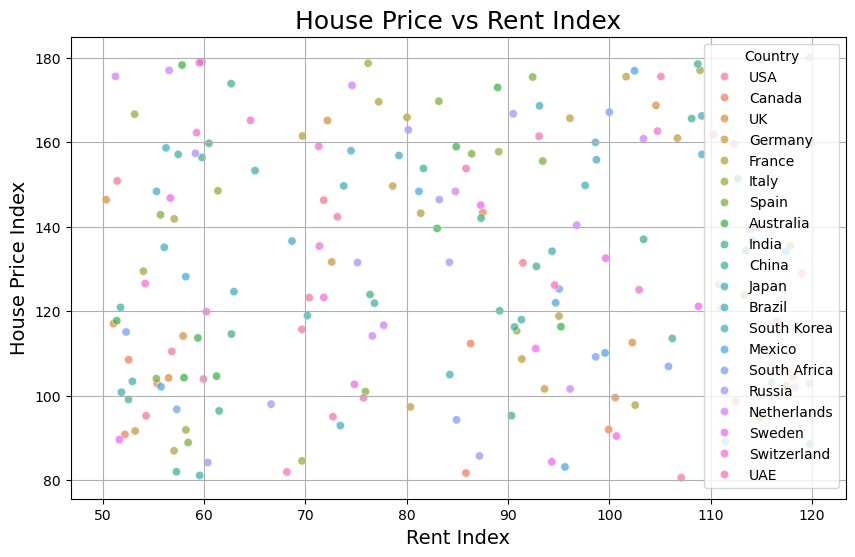

In [120]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Rent Index', y='House Price Index', hue='Country', alpha=0.7)
plt.title('House Price vs Rent Index', fontsize=18)
plt.xlabel('Rent Index', fontsize=14)
plt.ylabel('House Price Index', fontsize=14)
plt.legend(title="Country")
plt.grid(True)
plt.show()


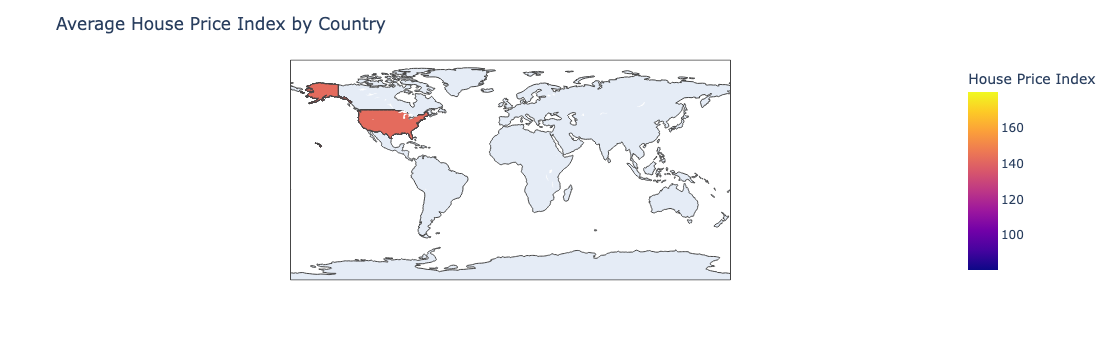

In [74]:
import plotly.express as px

fig = px.choropleth(df, 
                    locations='Country', 
                    color='House Price Index',
                    hover_name='Country',
                    color_continuous_scale=px.colors.sequential.Plasma)
fig.update_layout(title='Average House Price Index by Country')
fig.show()

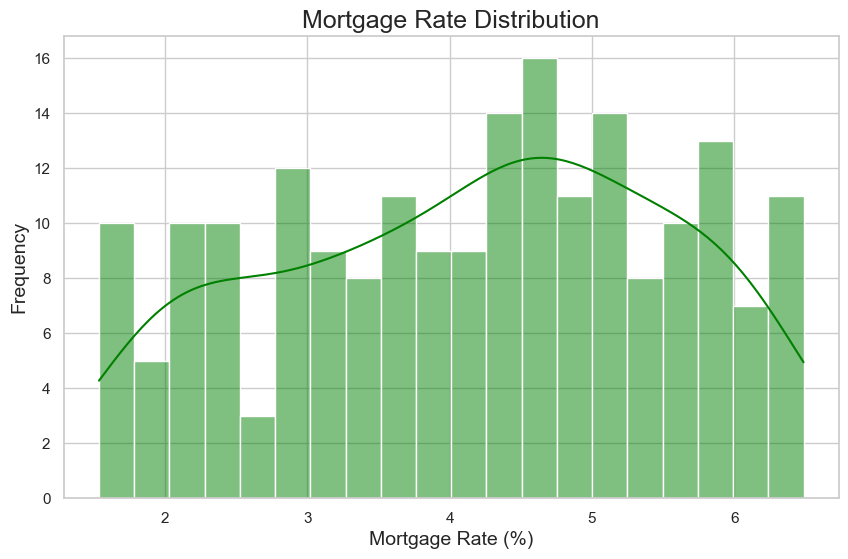

In [49]:
plt.figure(figsize=(10,6))
sns.histplot(df['Mortgage Rate (%)'], bins=20, kde=True, color='green')
plt.title('Mortgage Rate Distribution', fontsize=18)
plt.xlabel('Mortgage Rate (%)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True)
plt.show()

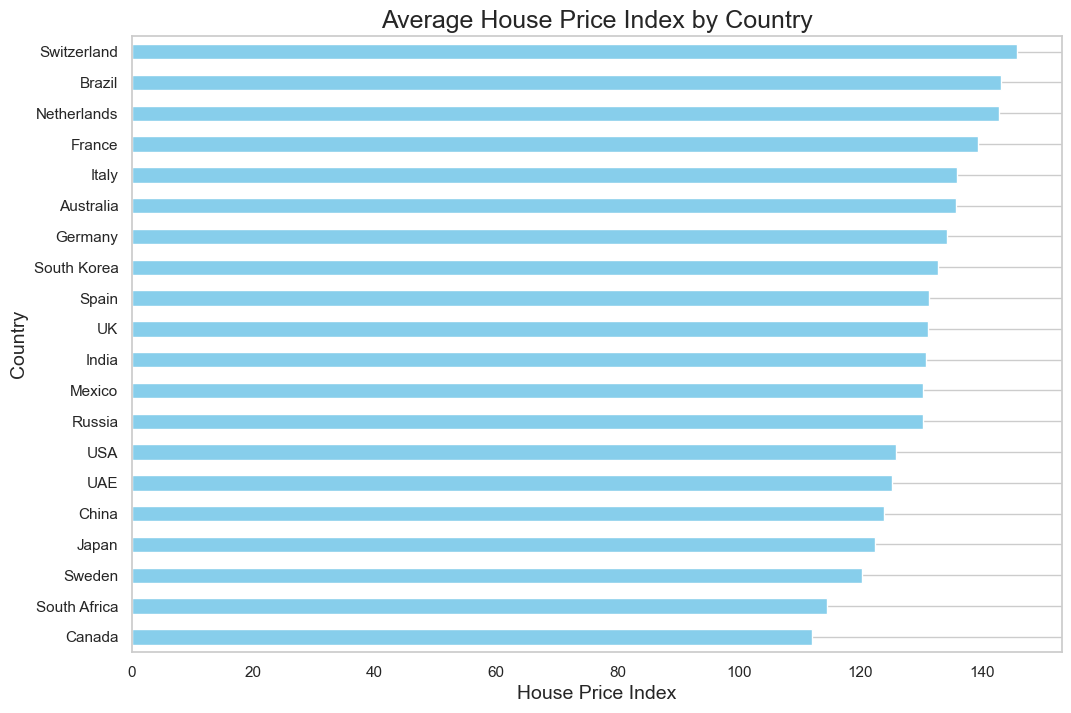

In [51]:
avg_house_price = df.groupby('Country')['House Price Index'].mean().sort_values()

plt.figure(figsize=(12,8))
avg_house_price.plot(kind='barh', color='skyblue')
plt.title('Average House Price Index by Country', fontsize=18)
plt.xlabel('House Price Index', fontsize=14)
plt.ylabel('Country', fontsize=14)
plt.grid(axis='x')
plt.show()

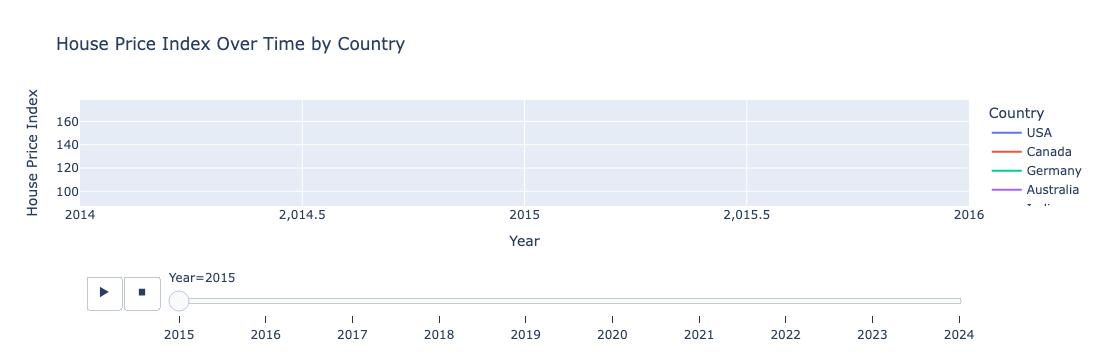

In [55]:
import plotly.express as px

# Filter the countries you want to animate
countries_to_plot = ['USA', 'Canada', 'Germany', 'Australia', 'India', 'South Africa']

# Create a filtered DataFrame
df_filtered = df[df['Country'].isin(countries_to_plot)]

# Create an animated line plot for House Price Index over time
fig = px.line(df_filtered, 
              x='Year', 
              y='House Price Index', 
              color='Country', 
              animation_frame='Year',  # This animates over the years
              line_group='Country', 
              title='Animated House Price Index Over Time')

# Show the plot
fig.update_layout(
    title='House Price Index Over Time by Country',
    xaxis_title='Year',
    yaxis_title='House Price Index'
)

fig.show()

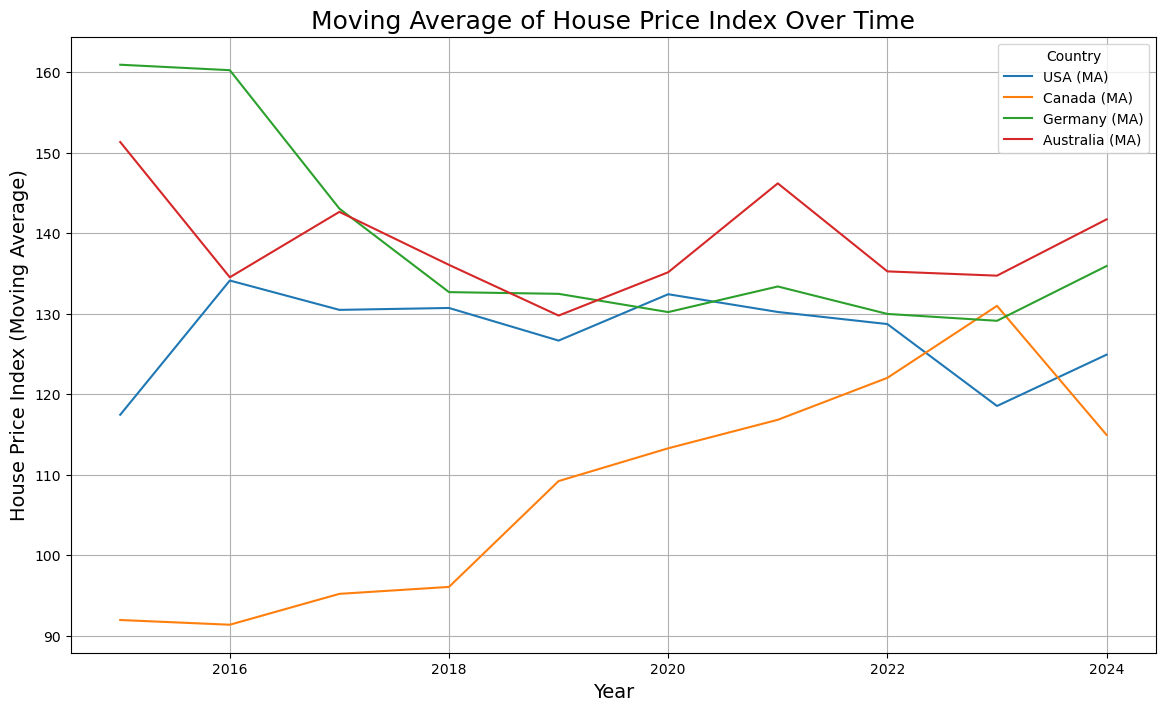

In [131]:
# Define the window size for the moving average
window_size = 5  # A 5-year moving average

# Create a new column in the DataFrame for moving average of House Price Index
df['House Price Index MA'] = df.groupby('Country')['House Price Index'].transform(lambda x: x.rolling(window=window_size, min_periods=1).mean())

# Plot the moving average for each country
plt.figure(figsize=(14,8))
for country in countries_to_plot:
    subset = df[df['Country'] == country]
    plt.plot(subset['Year'], subset['House Price Index MA'], label=f'{country} (MA)')

plt.title('Moving Average of House Price Index Over Time', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('House Price Index (Moving Average)', fontsize=14)
plt.legend(title="Country")
plt.grid(True)
plt.show()

In [ ]:
# To Oberserve Affects of the Pandemic

In [65]:
# Ensure Year is numeric (int), not categorical
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# filter for 2019 to 2024
df_covid = df[(df['Year'] >= 2019) & (df['Year'] <= 2024)]


In [ ]:
# Post-Covid: House Price Index

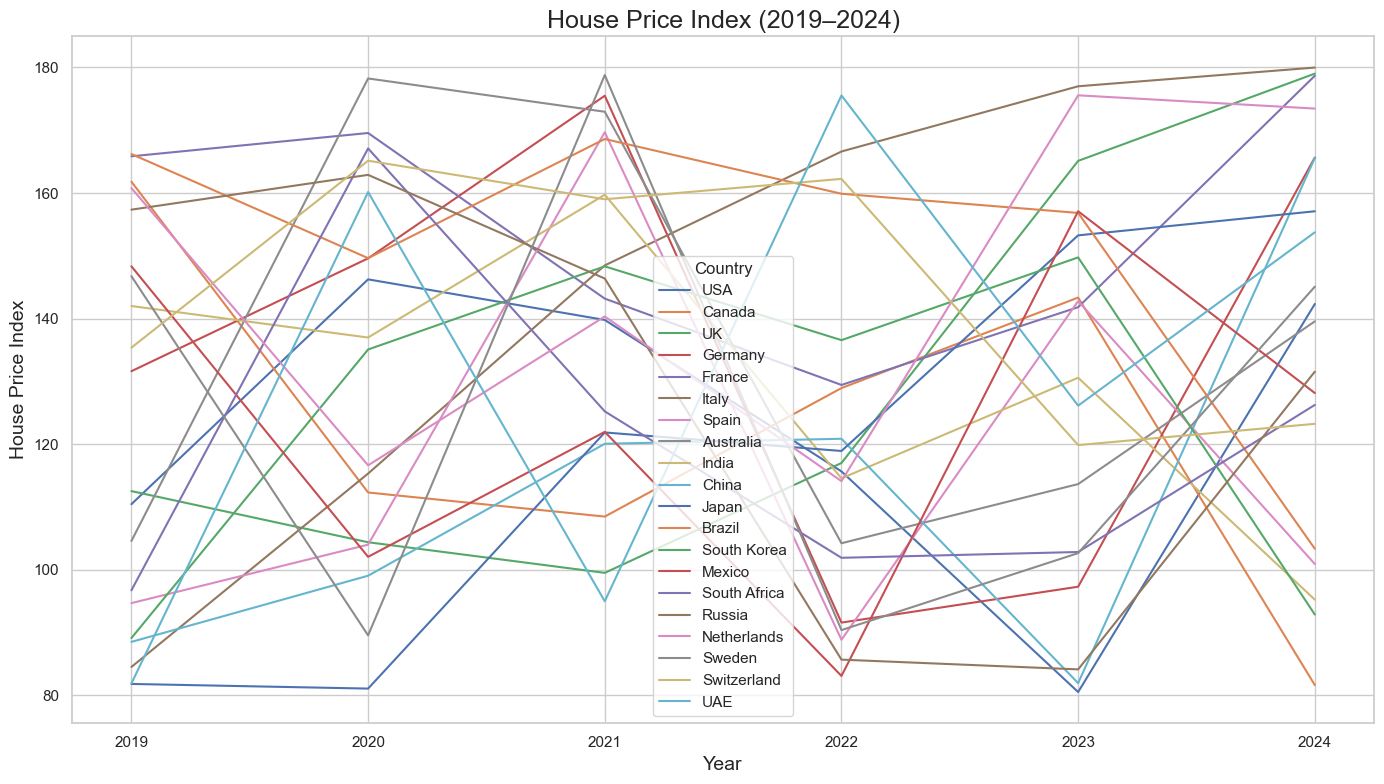

In [67]:
plt.figure(figsize=(14, 8))

for country in df_covid['Country'].unique():
    subset = df_covid[df_covid['Country'] == country]
    plt.plot(subset['Year'], subset['House Price Index'], label=country)

plt.title('House Price Index (2019–2024)', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('House Price Index', fontsize=14)
plt.legend(title='Country')
plt.grid(True)
plt.tight_layout()
plt.show()

# Post-Covid: Affordability Ratio Heatmap

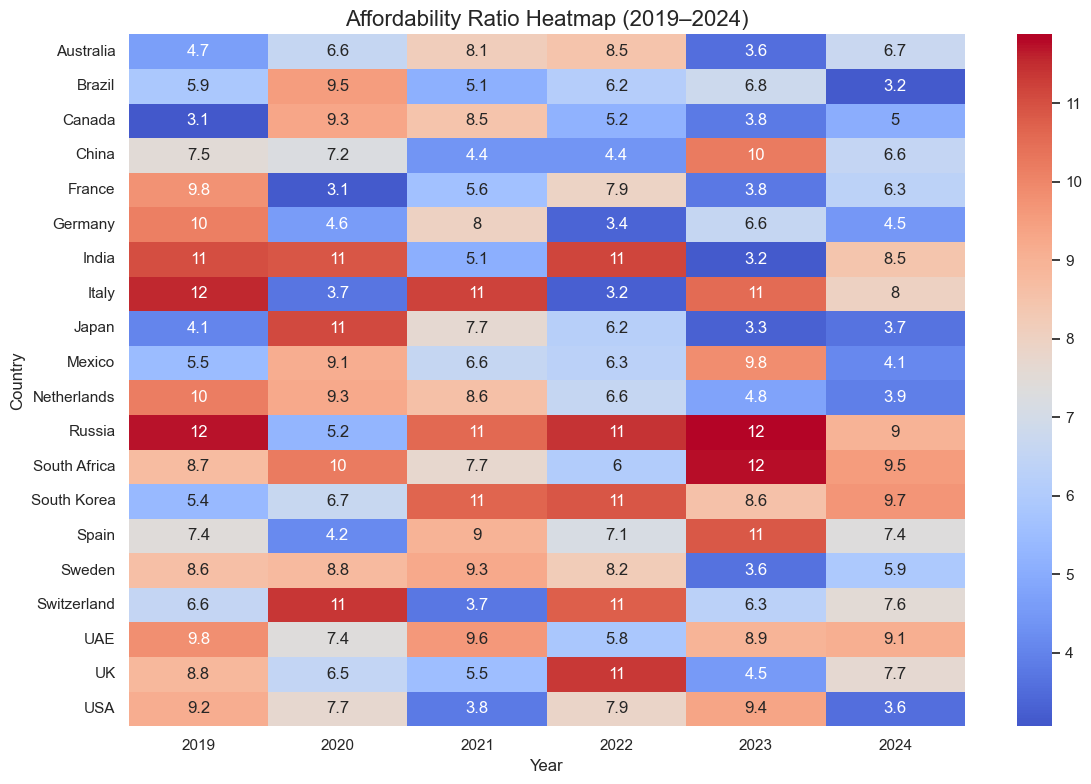

In [69]:
# Pivot the data for heatmap
heatmap_data = df_covid.pivot(index='Country', columns='Year', values='Affordability Ratio')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=heatmap_data.stack().mean())
plt.title('Affordability Ratio Heatmap (2019–2024)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


In [123]:
# Quick Insights
print("\nKey Insights:")
print("- Some countries have much higher average affordability ratios, indicating more challenging housing markets.")
print("- Mortgage rates have been mostly positive, but must monitor countries with sudden spikes or drops.")
print("- House prices generally trend upwards, but some countries show dips during certain years.")
print("- Inflation and GDP growth rates vary widely across countries, impacting affordability.")


Key Insights:
- Some countries have much higher average affordability ratios, indicating more challenging housing markets.
- Mortgage rates have been mostly positive, but must monitor countries with sudden spikes or drops.
- House prices generally trend upwards, but some countries show dips during certain years.
- Inflation and GDP growth rates vary widely across countries, impacting affordability.
